# Student Performance - Grade Prediction
Complete ML Pipeline for Grade Prediction
## Problem Statement
A university wants to predict a student's final Grade (`A`/`B`/`C`/`D`/`F`) based on attendance, scores, study habits, and demographic/background factors, so at-risk students can be identified early.
## Goal
Build a production-quality machine learning pipeline covering every step from raw data to final model selection — with justified decisions at each stage.
## Dataset
- Source: `Students_Performance_Dataset.csv`
- Records: 5,000 | Features: 22 input + 1 target (`Grade`)
- Class imbalance: Grades C/D dominate, A is extremely rare (~0.3%)
## Table of Contents
1. [Import Libraries](#1)
2. [Load & Understand Data](#2)
3. [Exploratory Data Analysis (EDA)](#3)
4. [Missing Value Handling](#4)
5. [Outlier Detection & Treatment](#5)
6. [Encoding Categorical Data](#6)
7. [Feature Engineering](#7)
8. [Feature Selection](#8)
9. [Scaling & Normalization](#9)
10. [Train-Test Split](#10)
11. [Model Training & Comparison](#11)
12. [Hyperparameter Tuning](#12)
13. [Final Model Evaluation](#13)
14. [Conclusion & Business Insights](#14) Preprocessing Philosophy: Every technique is applied only when justified by the data. Decisions are explained before code. Results are compared before and after where applicable.


## 1. Import Libraries


In [2]:
#  Core 
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

#  Visualization 
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
sns.set_style('whitegrid')
sns.set_palette('Set2')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size']      = 12

#  Preprocessing 
from sklearn.preprocessing    import StandardScaler, MinMaxScaler, LabelEncoder, OrdinalEncoder
from sklearn.model_selection  import (train_test_split, cross_val_score,
                                       StratifiedKFold, RandomizedSearchCV)

#  Models 
from sklearn.linear_model  import LogisticRegression
from sklearn.tree          import DecisionTreeClassifier
from sklearn.ensemble      import (RandomForestClassifier,
                                    GradientBoostingClassifier,
                                    BaggingClassifier,
                                    AdaBoostClassifier,
                                    ExtraTreesClassifier)
from sklearn.neighbors     import KNeighborsClassifier
from sklearn.naive_bayes   import GaussianNB
from sklearn.svm           import SVC

#  Metrics 
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    ConfusionMatrixDisplay, f1_score, precision_score, recall_score, accuracy_score
)

#  Optional: XGBoost 
try:
    import xgboost as xgb
    XGB_AVAILABLE = True
    print('XGBoost loaded ')
except ImportError:
    XGB_AVAILABLE = False
    print('XGBoost not installed — install via: pip install xgboost')

#  Optional: SMOTE (imbalanced-learn) 
try:
    from imblearn.over_sampling import SMOTE
    SMOTE_AVAILABLE = True
    print('SMOTE (imbalanced-learn) loaded ')
except ImportError:
    SMOTE_AVAILABLE = False
    print('imbalanced-learn not installed — install via: pip install imbalanced-learn')

print('\n All core libraries loaded successfully')


XGBoost loaded 
SMOTE (imbalanced-learn) loaded 

 All core libraries loaded successfully


## 2. Load & Understand Data


### Step 2.1 — Load Dataset
Standard comma-separated CSV with student records.


In [46]:
df = pd.read_csv('Students_Performance_Dataset.csv')
print(f'Dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')
df.head()

Dataset loaded: 5,000 rows x 23 columns


,Student_ID,First_Name,Last_Name,Email,Gender,Age,Department,Attendance (%),Midterm_Score,Final_Score,...,Projects_Score,Total_Score,Grade,Study_Hours_per_Week,Extracurricular_Activities,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night
0,S1000,Omar,Williams,student0@university.com,Female,22,Mathematics,97.36,40.61,59.61,...,62.84,59.8865,F,10.3,Yes,No,Master's,Medium,1,5.9
1,S1001,Maria,Brown,student1@university.com,Male,18,Business,97.71,57.27,74.00,...,98.23,81.9170,B,27.1,No,No,High School,Low,4,4.3
2,S1002,Ahmed,Jones,student2@university.com,Male,24,Engineering,99.52,41.84,63.85,...,91.22,67.7170,D,12.4,Yes,No,High School,Low,9,6.1
3,S1003,Omar,Williams,student3@university.com,Female,24,Engineering,90.38,45.65,44.44,...,55.48,51.6535,F,25.5,No,Yes,High School,Low,8,4.9
4,S1004,John,Smith,student4@university.com,Female,23,CS,59.41,53.13,61.77,...,87.43,71.4030,C,13.3,Yes,No,Master's,Medium,6,4.5


### Step 2.2 — Basic Info & Data Types


In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  5000 non-null   str    
 1   First_Name                  5000 non-null   str    
 2   Last_Name                   5000 non-null   str    
 3   Email                       5000 non-null   str    
 4   Gender                      5000 non-null   str    
 5   Age                         5000 non-null   int64  
 6   Department                  5000 non-null   str    
 7   Attendance (%)              5000 non-null   float64
 8   Midterm_Score               5000 non-null   float64
 9   Final_Score                 5000 non-null   float64
 10  Assignments_Avg             5000 non-null   float64
 11  Quizzes_Avg                 5000 non-null   float64
 12  Participation_Score         5000 non-null   float64
 13  Projects_Score              5000 non-null   

### Step 2.3 — Statistical Summary


In [5]:
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Student_ID,5000,5000,S1000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
First_Name,5000,8,Maria,657,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Last_Name,5000,6,Johnson,868,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Email,5000,5000,student0@university.com,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,5000,2,Male,2551,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,5000.0,NaN,NaN,NaN,21.0484,1.989786,18.0,19.0,21.0,23.0,24.0
Department,5000,4,Engineering,1274,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Attendance (%),5000.0,NaN,NaN,NaN,75.356076,14.392716,50.01,62.945,75.67,87.8625,100.0
Midterm_Score,5000.0,NaN,NaN,NaN,70.701924,17.436325,40.0,55.7075,70.86,85.76,99.99
Final_Score,5000.0,NaN,NaN,NaN,69.546552,17.108996,40.01,54.6975,69.485,83.9225,99.98


### Step 2.4 — Drop Identifier / PII Columns
`Student_ID`, `First_Name`, `Last_Name`, `Email` carry no predictive signal and are dropped immediately to avoid leakage and noise.


In [6]:
drop_cols = ['Student_ID', 'First_Name', 'Last_Name', 'Email']
df = df.drop(columns=drop_cols)
print(f'Dropped: {drop_cols}')
print(f'Remaining shape: {df.shape}')


Dropped: ['Student_ID', 'First_Name', 'Last_Name', 'Email']
Remaining shape: (5000, 19)


### Step 2.5 — Target Variable Distribution
`Grade` is the target — a multi-class classification problem.


Grade
C    2307
D    1760
B     638
F     279
A      16
Name: count, dtype: int64

Proportion (%):
Grade
C    46.14
D    35.20
B    12.76
F     5.58
A     0.32
Name: proportion, dtype: float64


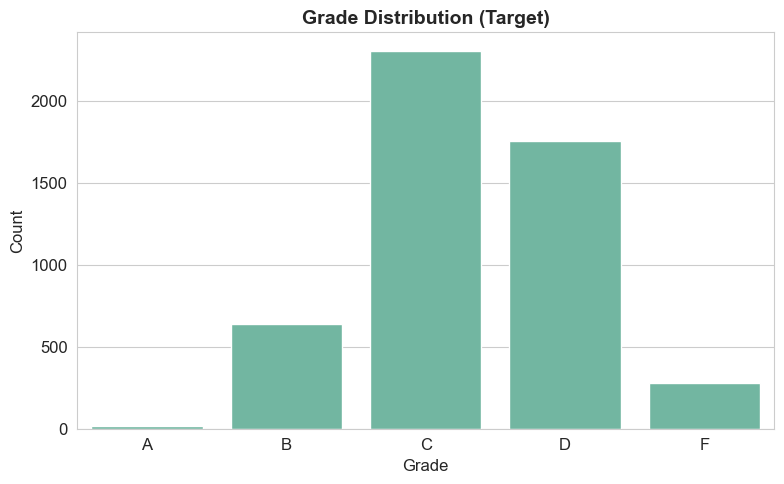

In [7]:
print(df['Grade'].value_counts())
print('\nProportion (%):')
print((df['Grade'].value_counts(normalize=True) * 100).round(2))

fig, ax = plt.subplots(figsize=(8, 5))
order = ['A', 'B', 'C', 'D', 'F']
sns.countplot(data=df, x='Grade', order=order, ax=ax)
ax.set_title('Grade Distribution (Target)', fontsize=14, fontweight='bold')
ax.set_xlabel('Grade')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()


## 3. Exploratory Data Analysis (EDA)


### Step 3.1 — Numerical Feature Distributions


Numerical columns (12): ['Age', 'Attendance (%)', 'Midterm_Score', 'Final_Score', 'Assignments_Avg', 'Quizzes_Avg', 'Participation_Score', 'Projects_Score', 'Total_Score', 'Study_Hours_per_Week', 'Stress_Level (1-10)', 'Sleep_Hours_per_Night']


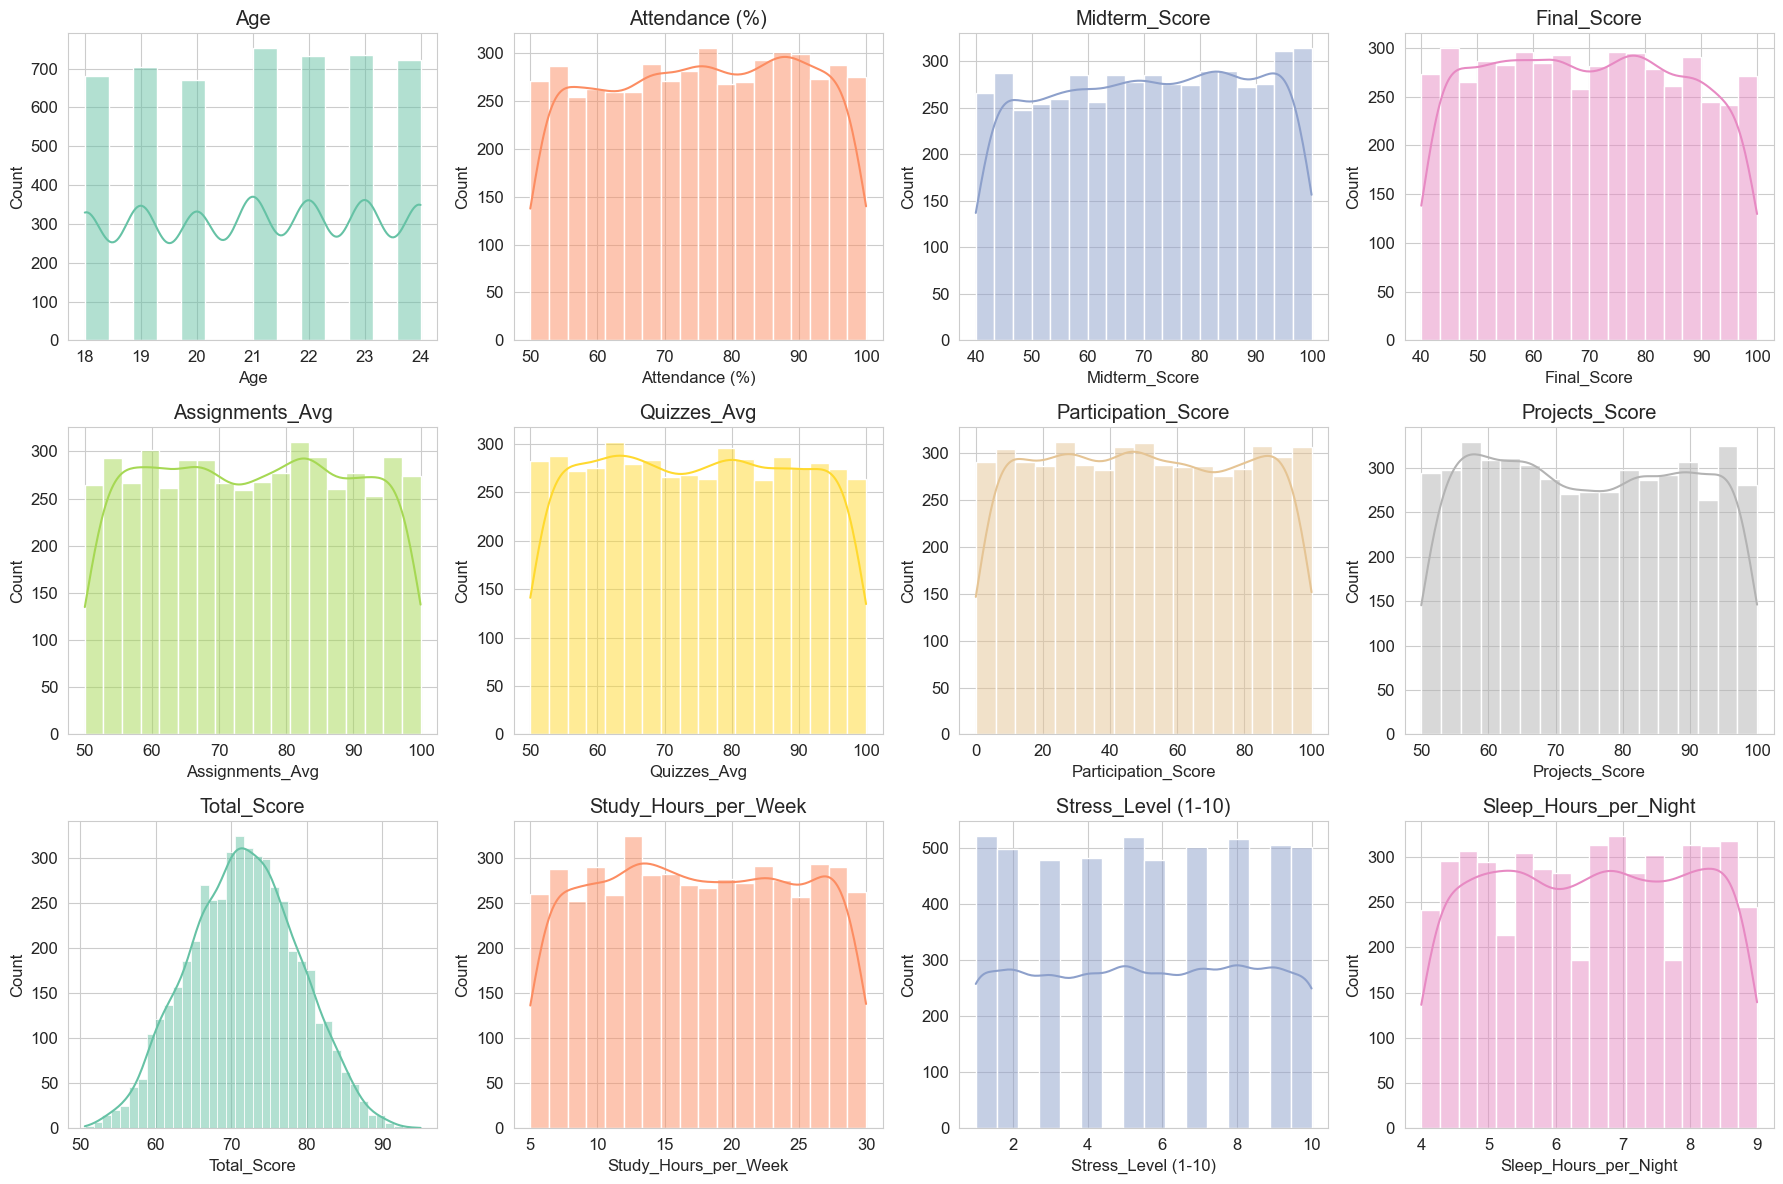

In [8]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f'Numerical columns ({len(num_cols)}): {num_cols}')

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color=sns.color_palette('Set2')[i % 8])
    axes[i].set_title(col)
for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()


### Step 3.2 — Correlation Heatmap (Numerical Features)


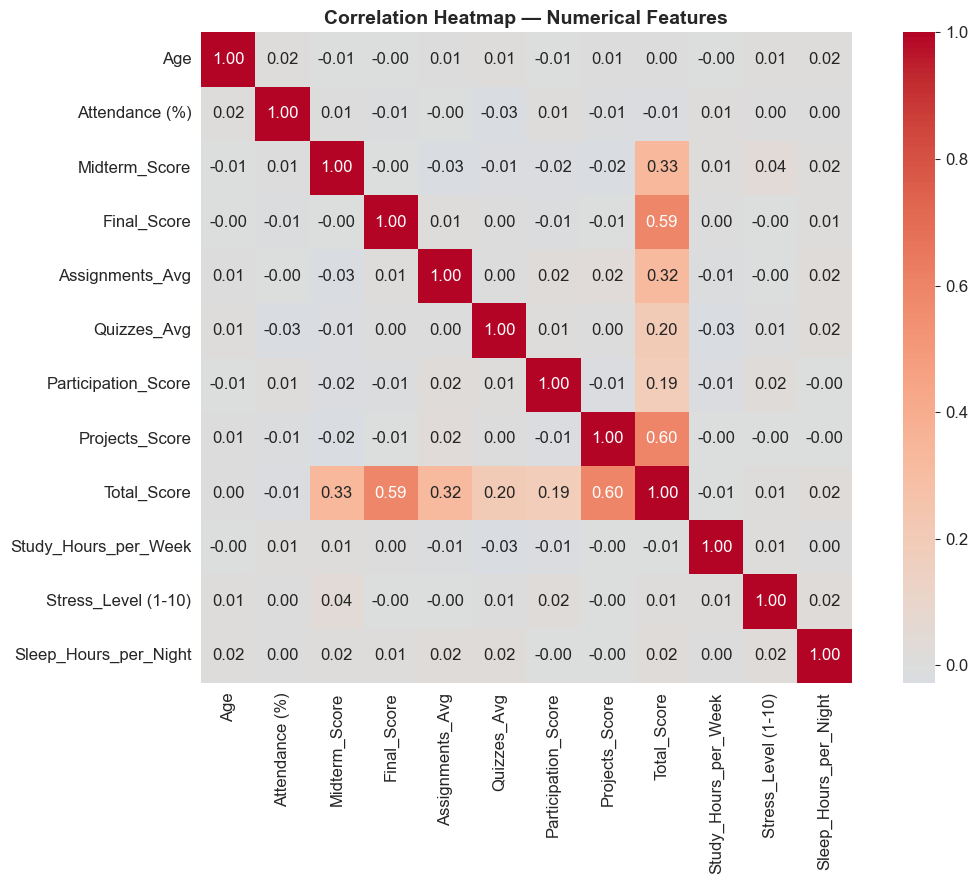

In [9]:
plt.figure(figsize=(12, 9))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation Heatmap — Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### Step 3.3 — Categorical Feature Distributions


Categorical columns (6): ['Gender', 'Department', 'Extracurricular_Activities', 'Internet_Access_at_Home', 'Parent_Education_Level', 'Family_Income_Level']


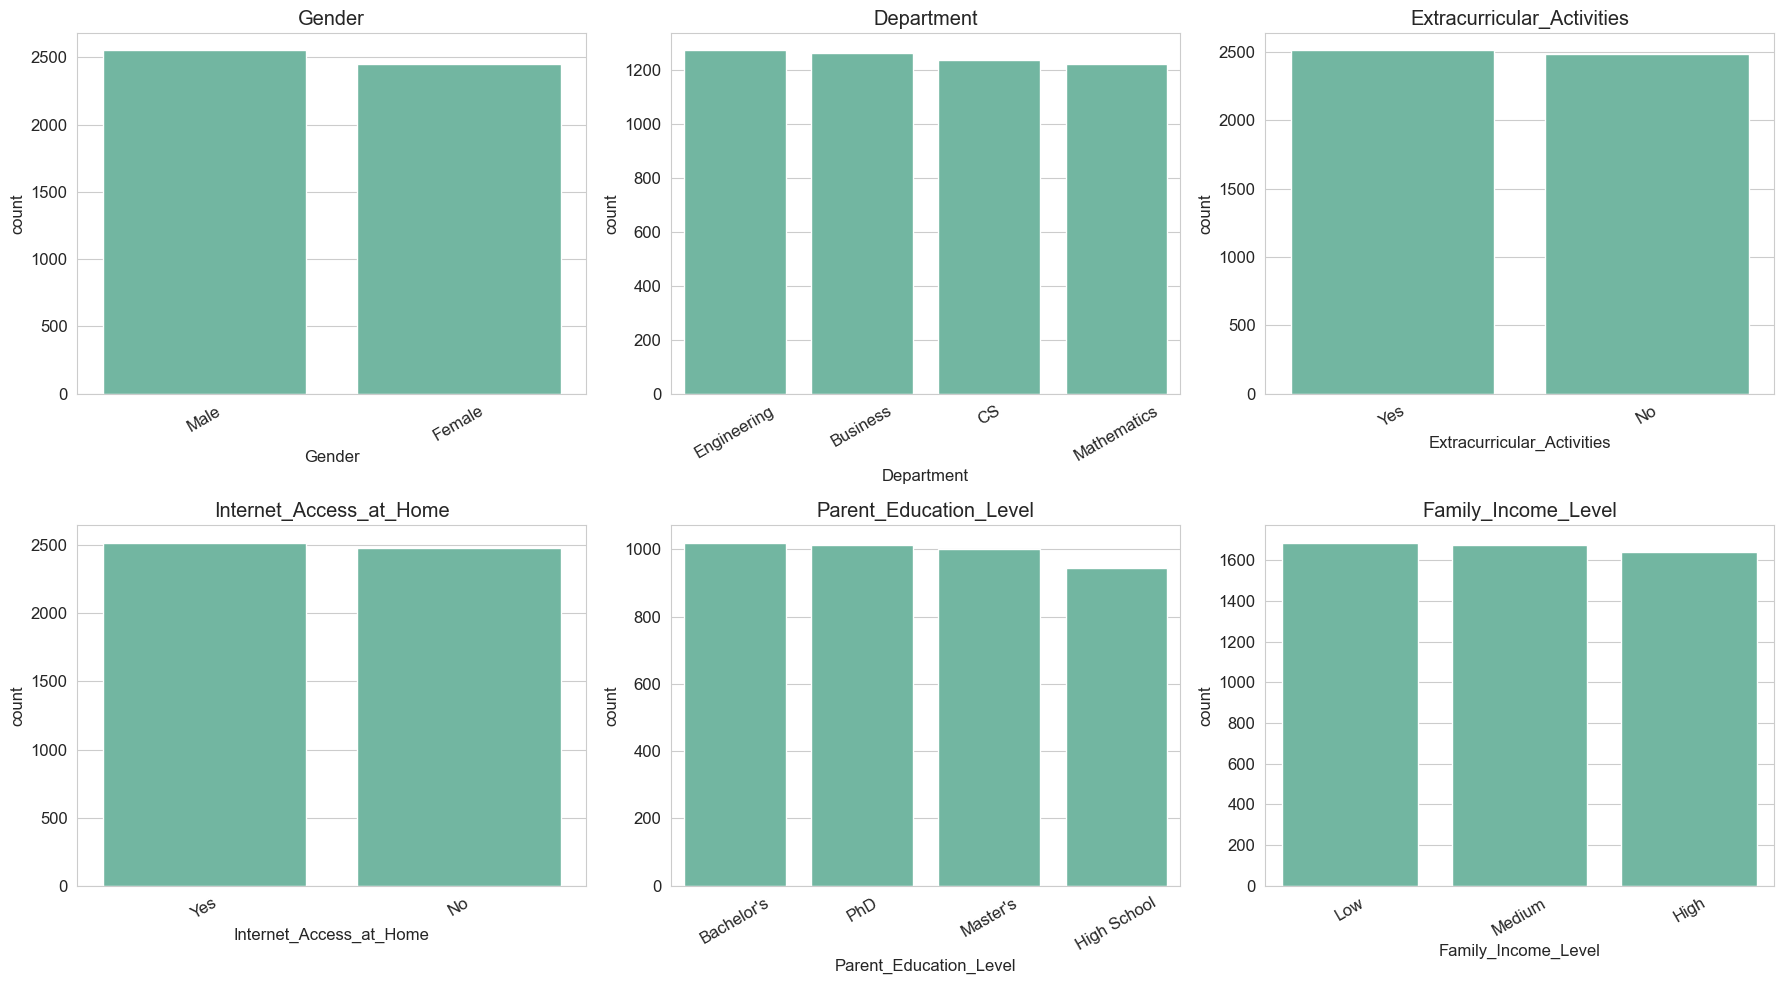

In [10]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols.remove('Grade')
print(f'Categorical columns ({len(cat_cols)}): {cat_cols}')

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=30)
for j in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()


### Step 3.4 — Grade vs Key Numerical Features
How do scores, attendance and study hours vary across grades?


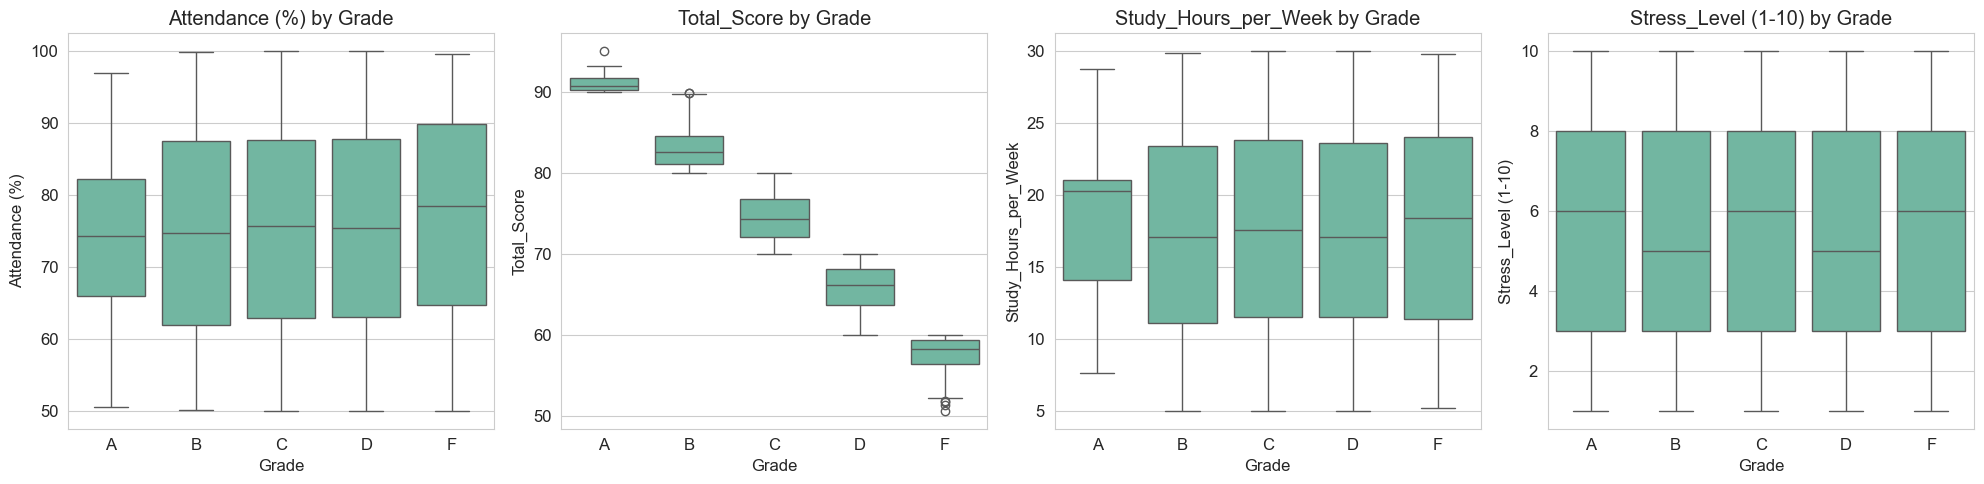

In [11]:
key_features = ['Attendance (%)', 'Total_Score', 'Study_Hours_per_Week', 'Stress_Level (1-10)']
order = ['A', 'B', 'C', 'D', 'F']

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for i, col in enumerate(key_features):
    sns.boxplot(data=df, x='Grade', y=col, order=order, ax=axes[i])
    axes[i].set_title(f'{col} by Grade')
plt.tight_layout()
plt.show()


### Step 3.5 — Grade vs Department


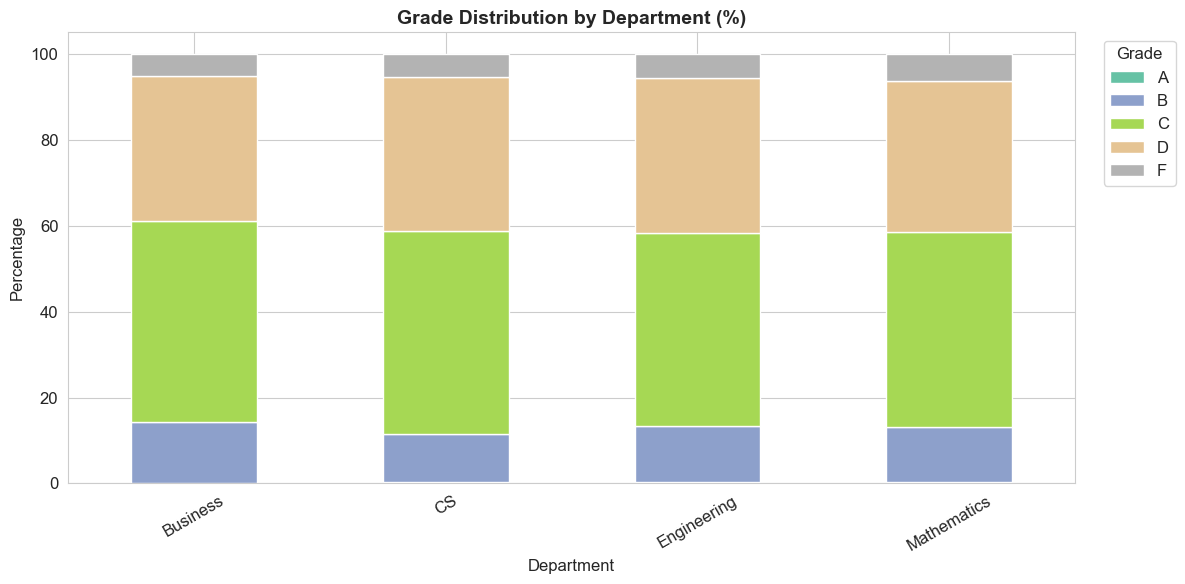

In [12]:
ct = pd.crosstab(df['Department'], df['Grade'], normalize='index') * 100
ct = ct[['A','B','C','D','F']]
ct.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='Set2')
plt.title('Grade Distribution by Department (%)', fontsize=14, fontweight='bold')
plt.ylabel('Percentage')
plt.legend(title='Grade', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


## 4. Missing Value Handling


### Step 4.1 — Identify Missing Values
Check for `NaN`s across all columns. `Parent_Education_Level` has missing entries.


In [13]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]
print(missing_df)


                        Missing Count  Missing %
Parent_Education_Level           1025       20.5


### Step 4.2 — Handle Missing `Parent_Education_Level`
~20% of rows are missing this categorical field. Rather than dropping ~1,000 rows (significant data loss),
we add an explicit `'Unknown'` category. This preserves all rows and lets tree-based models
learn whether "unknown parent education" itself carries signal — and one-hot encoding will simply add a level for it.


In [14]:
print('Before:')
print(df['Parent_Education_Level'].isnull().sum(), 'missing values')

df['Parent_Education_Level'] = df['Parent_Education_Level'].fillna('Unknown')

print('\nAfter:')
print(df['Parent_Education_Level'].value_counts())
print('\nRemaining missing values in dataset:', df.isnull().sum().sum())


Before:
1025 missing values

After:
Parent_Education_Level
Unknown        1025
Bachelor's     1020
PhD            1012
Master's       1000
High School     943
Name: count, dtype: int64

Remaining missing values in dataset: 0


## 5. Outlier Detection & Treatment


### Step 5.1 — IQR-Based Outlier Detection
Check each numerical column for values beyond 1.5×IQR from Q1/Q3.


In [15]:
def iqr_outlier_summary(data, cols):
    rows = []
    for col in cols:
        Q1, Q3 = data[col].quantile([0.25, 0.75])
        IQR = Q3 - Q1
        lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
        n_out = ((data[col] < lower) | (data[col] > upper)).sum()
        rows.append({'Column': col, 'Lower': round(lower,2), 'Upper': round(upper,2),
                      'Outliers': n_out, 'Outlier %': round(n_out/len(data)*100, 2)})
    return pd.DataFrame(rows)

outlier_summary = iqr_outlier_summary(df, num_cols)
outlier_summary


,Column,Lower,Upper,Outliers,Outlier %
0,Age,13.00,29.00,0,0.00
1,Attendance (%),25.57,125.24,0,0.00
2,Midterm_Score,10.63,130.84,0,0.00
3,Final_Score,10.86,127.76,0,0.00
4,Assignments_Avg,24.82,124.87,0,0.00
5,Quizzes_Avg,24.95,124.70,0,0.00
6,Participation_Score,-50.56,151.14,0,0.00
7,Projects_Score,23.48,126.12,0,0.00
8,Total_Score,51.27,91.98,4,0.08
9,Study_Hours_per_Week,-6.80,42.00,0,0.00


### Step 5.2 — Decision on Outlier Treatment
The outlier percentages are very low (well under 1% for all columns) and all values fall within
realistic, valid ranges (e.g. scores 0-100, attendance 0-100, stress 1-10). These are not data errors —
they reflect genuinely high/low-performing students, which is exactly the signal the model needs to learn.
Decision: No capping or removal. Treating these as outliers and capping them would remove
exactly the extreme performers (e.g. true `A` and `F` students) that the model must learn to identify.


In [16]:
print('No outlier treatment applied — extreme values represent genuine, valid student performance')
print(f'Dataset shape remains: {df.shape}')


No outlier treatment applied — extreme values represent genuine, valid student performance
Dataset shape remains: (5000, 19)


## 6. Encoding Categorical Data


### Step 6.1 — Encoding Strategy
Column | Encoding | Justification
`Gender`, `Extracurricular_Activities`, `Internet_Access_at_Home` | Binary mapping | Two categories only
`Department`, `Family_Income_Level` | One-Hot Encoding | Nominal, no natural order
`Parent_Education_Level` | Ordinal Encoding | Natural hierarchy: Unknown < High School < Bachelor's < Master's < PhD
`Grade` (target) | Label Encoding | Ordinal target (A=best ... F=worst) for modelling, kept readable for reports


### Step 6.2 — Binary Columns


In [17]:
binary_maps = {
    'Gender': {'Male': 0, 'Female': 1},
    'Extracurricular_Activities': {'No': 0, 'Yes': 1},
    'Internet_Access_at_Home': {'No': 0, 'Yes': 1},
}
for col, mapping in binary_maps.items():
    df[col] = df[col].map(mapping)

df[list(binary_maps.keys())].head()


,Gender,Extracurricular_Activities,Internet_Access_at_Home
0,1,1,0
1,0,0,0
2,0,1,0
3,1,0,1
4,1,1,0


### Step 6.3 — Ordinal Encoding: `Parent_Education_Level`


In [18]:
edu_order = ['Unknown', 'High School', "Bachelor's", "Master's", 'PhD']
edu_map = {level: i for i, level in enumerate(edu_order)}
df['Parent_Education_Level'] = df['Parent_Education_Level'].map(edu_map)
print(edu_map)
df['Parent_Education_Level'].value_counts().sort_index()


{'Unknown': 0, 'High School': 1, "Bachelor's": 2, "Master's": 3, 'PhD': 4}


Parent_Education_Level
0    1025
1     943
2    1020
3    1000
4    1012
Name: count, dtype: int64

### Step 6.4 — Ordinal Encoding: `Family_Income_Level`


In [19]:
income_order = ['Low', 'Medium', 'High']
income_map = {level: i for i, level in enumerate(income_order)}
df['Family_Income_Level'] = df['Family_Income_Level'].map(income_map)
print(income_map)
df['Family_Income_Level'].value_counts().sort_index()


{'Low': 0, 'Medium': 1, 'High': 2}


Family_Income_Level
0    1687
1    1674
2    1639
Name: count, dtype: int64

### Step 6.5 — One-Hot Encoding: `Department`


In [20]:
df = pd.get_dummies(df, columns=['Department'], prefix='Dept', drop_first=True)
print(f'Shape after one-hot encoding: {df.shape}')
df.head()


Shape after one-hot encoding: (5000, 21)


,Gender,Age,Attendance (%),Midterm_Score,Final_Score,Assignments_Avg,Quizzes_Avg,Participation_Score,Projects_Score,Total_Score,...,Study_Hours_per_Week,Extracurricular_Activities,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night,Dept_CS,Dept_Engineering,Dept_Mathematics
0,1,22,97.36,40.61,59.61,73.69,53.17,73.4,62.84,59.8865,...,10.3,1,0,3,1,1,5.9,False,False,True
1,0,18,97.71,57.27,74.00,74.23,98.23,88.0,98.23,81.9170,...,27.1,0,0,1,0,4,4.3,False,False,False
2,0,24,99.52,41.84,63.85,85.85,50.00,4.7,91.22,67.7170,...,12.4,1,0,1,0,9,6.1,False,True,False
3,1,24,90.38,45.65,44.44,68.10,66.27,4.2,55.48,51.6535,...,25.5,0,1,1,0,8,4.9,False,True,False
4,1,23,59.41,53.13,61.77,67.66,83.98,64.3,87.43,71.4030,...,13.3,1,0,3,1,6,4.5,True,False,False


### Step 6.6 — Encode Target Variable `Grade`


In [21]:
grade_order = ['A', 'B', 'C', 'D', 'F']
grade_map = {g: i for i, g in enumerate(grade_order)}
df['Grade_Encoded'] = df['Grade'].map(grade_map)
print(grade_map)
df[['Grade', 'Grade_Encoded']].head()


{'A': 0, 'B': 1, 'C': 2, 'D': 3, 'F': 4}


,Grade,Grade_Encoded
0,F,4
1,B,1
2,D,3
3,F,4
4,C,2


## 7. Feature Engineering


### Step 7.1 — `Avg_Academic_Score`
Combine assessment-related scores into a single composite measure of overall academic performance.


In [22]:
df['Avg_Academic_Score'] = df[['Midterm_Score','Final_Score','Assignments_Avg',
                               'Quizzes_Avg','Projects_Score']].mean(axis=1)
df[['Avg_Academic_Score','Total_Score']].describe()


,Avg_Academic_Score,Total_Score
count,5000.000000,5000.000000
mean,72.964812,71.652097
std,6.947503,7.230097
min,49.520000,50.602000
25%,68.213500,66.533875
50%,73.044000,71.696250
75%,77.840000,76.711625
max,94.104000,95.091500


### Step 7.2 — `Engagement_Score`
Combine attendance and participation into a single "engagement" signal — both reflect how
involved a student is in the course, separate from raw test performance.


In [23]:
df['Engagement_Score'] = (df['Attendance (%)'] + df['Participation_Score']) / 2
df[['Engagement_Score']].describe()


,Engagement_Score
count,5000.000000
mean,62.659898
std,16.241233
min,25.390000
25%,50.095000
50%,62.715000
75%,75.475000
max,99.550000


### Step 7.3 — `Sleep_Stress_Balance`
Ratio of sleep to stress — a low value indicates a stressed, sleep-deprived student
(potential risk indicator for poor performance).


In [24]:
df['Sleep_Stress_Balance'] = df['Sleep_Hours_per_Night'] / df['Stress_Level (1-10)']
df[['Sleep_Stress_Balance']].describe()


,Sleep_Stress_Balance
count,5000.000000
mean,1.920099
std,1.828166
min,0.400000
25%,0.814286
50%,1.169048
75%,2.200000
max,9.000000


### Step 7.4 — `Study_Efficiency`
Total score achieved per hour of study — captures how efficiently a student converts
study time into results, not just raw effort.


In [25]:
df['Study_Efficiency'] = df['Total_Score'] / df['Study_Hours_per_Week'].replace(0, np.nan)
df['Study_Efficiency'] = df['Study_Efficiency'].fillna(df['Study_Efficiency'].median())
df[['Study_Efficiency']].describe()


,Study_Efficiency
count,5000.000000
mean,5.116717
std,2.841698
min,1.812772
25%,3.012890
50%,4.115459
75%,6.262034
max,17.243900


### Step 7.5 — `Is_High_Risk`
Binary flag for students with low attendance (<60%) AND high stress (>=7) — a quick
early-warning indicator commonly used by academic advisors.


In [26]:
df['Is_High_Risk'] = ((df['Attendance (%)'] < 60) & (df['Stress_Level (1-10)'] >= 7)).astype(int)
print(df['Is_High_Risk'].value_counts())
print('\nGrade distribution for high-risk students:')
print(df[df['Is_High_Risk'] == 1]['Grade'].value_counts(normalize=True).round(3))


Is_High_Risk
0    4602
1     398
Name: count, dtype: int64

Grade distribution for high-risk students:
Grade
C    0.510
D    0.317
B    0.126
F    0.043
A    0.005
Name: proportion, dtype: float64


### Step 7.6 — Validate New Features via Correlation with Target


In [27]:
new_feats = ['Avg_Academic_Score', 'Engagement_Score', 'Sleep_Stress_Balance',
              'Study_Efficiency', 'Is_High_Risk']
corr_with_target = df[new_feats + ['Grade_Encoded']].corr()['Grade_Encoded'].drop('Grade_Encoded')
print('Correlation of new features with Grade_Encoded (lower grade = better, so negative corr = good):')
print(corr_with_target.round(3))


Correlation of new features with Grade_Encoded (lower grade = better, so negative corr = good):
Avg_Academic_Score     -0.855
Engagement_Score       -0.154
Sleep_Stress_Balance    0.017
Study_Efficiency       -0.170
Is_High_Risk           -0.024
Name: Grade_Encoded, dtype: float64


## 8. Feature Selection


### Step 8.1 — Drop Redundant Raw Components
`Avg_Academic_Score` is highly correlated with `Total_Score` and its components
(`Midterm_Score`, `Final_Score`, `Assignments_Avg`, `Quizzes_Avg`, `Projects_Score`).
Keep `Total_Score` (the original ground-truth aggregate used to derive `Grade`) and drop
the redundant engineered duplicate plus the now-redundant text `Grade` column.


In [28]:
drop_redundant = ['Avg_Academic_Score', 'Grade']
df_model = df.drop(columns=drop_redundant)
print(f'Dropped: {drop_redundant}')
print(f'Shape: {df_model.shape}')
df_model.columns.tolist()


Dropped: ['Avg_Academic_Score', 'Grade']
Shape: (5000, 25)


['Gender',
 'Age',
 'Attendance (%)',
 'Midterm_Score',
 'Final_Score',
 'Assignments_Avg',
 'Quizzes_Avg',
 'Participation_Score',
 'Projects_Score',
 'Total_Score',
 'Study_Hours_per_Week',
 'Extracurricular_Activities',
 'Internet_Access_at_Home',
 'Parent_Education_Level',
 'Family_Income_Level',
 'Stress_Level (1-10)',
 'Sleep_Hours_per_Night',
 'Dept_CS',
 'Dept_Engineering',
 'Dept_Mathematics',
 'Grade_Encoded',
 'Engagement_Score',
 'Sleep_Stress_Balance',
 'Study_Efficiency',
 'Is_High_Risk']

### Step 8.2 — Random Forest Feature Importance
Train a quick Random Forest on all remaining features to rank importance and
identify near-zero-importance features for removal.


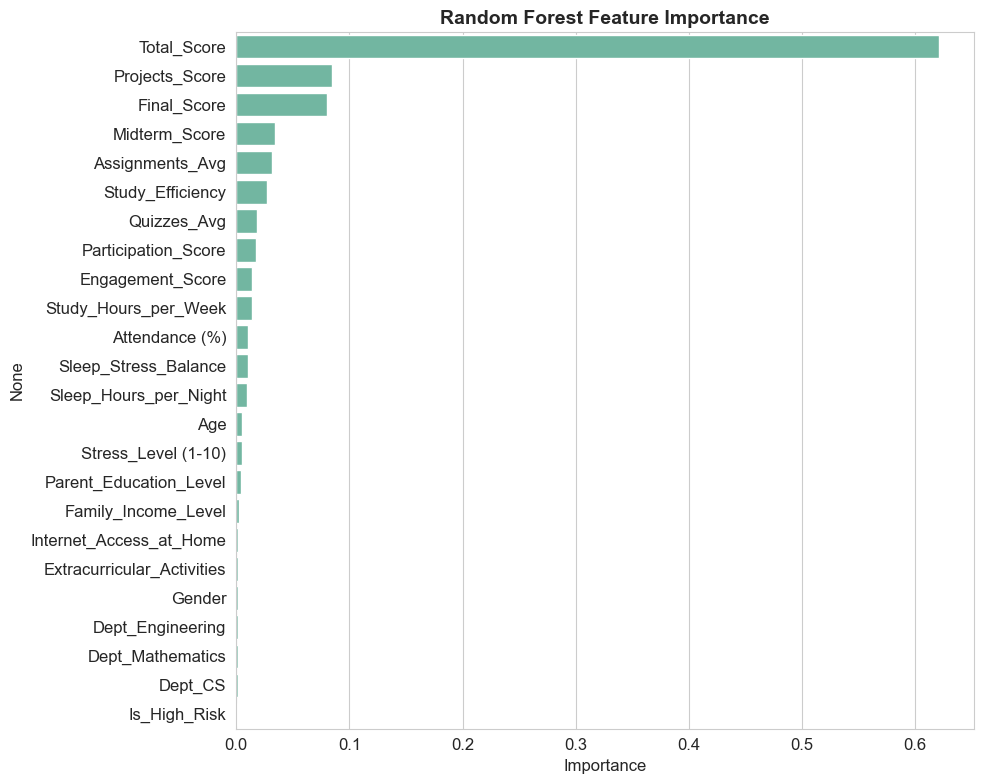

Total_Score                   0.620808
Projects_Score                0.084582
Final_Score                   0.080549
Midterm_Score                 0.034457
Assignments_Avg               0.031361
Study_Efficiency              0.027110
Quizzes_Avg                   0.018423
Participation_Score           0.017948
Engagement_Score              0.014034
Study_Hours_per_Week          0.013780
Attendance (%)                0.010584
Sleep_Stress_Balance          0.010106
Sleep_Hours_per_Night         0.009223
Age                           0.005225
Stress_Level (1-10)           0.005048
Parent_Education_Level        0.004041
Family_Income_Level           0.002637
Internet_Access_at_Home       0.001715
Extracurricular_Activities    0.001597
Gender                        0.001561
Dept_Engineering              0.001536
Dept_Mathematics              0.001437
Dept_CS                       0.001402
Is_High_Risk                  0.000837
dtype: float64


In [29]:
X_temp = df_model.drop(columns=['Grade_Encoded'])
y_temp = df_model['Grade_Encoded']

rf_temp = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_temp.fit(X_temp, y_temp)

importances = pd.Series(rf_temp.feature_importances_, index=X_temp.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=importances.values, y=importances.index, color=sns.color_palette('Set2')[0])
plt.title('Random Forest Feature Importance', fontsize=14, fontweight='bold')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print(importances)


### Step 8.3 — Remove Low-Importance Features
Drop features with importance below 0.005 — these contribute negligibly and add noise/dimensionality.


In [30]:
threshold = 0.005
low_importance = importances[importances < threshold].index.tolist()
print(f'Dropping {len(low_importance)} low-importance features: {low_importance}')

df_model = df_model.drop(columns=low_importance)
print(f'\nFinal shape: {df_model.shape}')


Dropping 9 low-importance features: ['Parent_Education_Level', 'Family_Income_Level', 'Internet_Access_at_Home', 'Extracurricular_Activities', 'Gender', 'Dept_Engineering', 'Dept_Mathematics', 'Dept_CS', 'Is_High_Risk']

Final shape: (5000, 16)


## 9. Scaling & Normalization


### Step 9.1 — Separate Features & Target
Scaling is applied after the train-test split (next step) to avoid data leakage,
but we first separate `X` and `y` here.


In [31]:
X = df_model.drop(columns=['Grade_Encoded'])
y = df_model['Grade_Encoded']

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'\nFeature columns: {X.columns.tolist()}')


X shape: (5000, 15)
y shape: (5000,)

Feature columns: ['Age', 'Attendance (%)', 'Midterm_Score', 'Final_Score', 'Assignments_Avg', 'Quizzes_Avg', 'Participation_Score', 'Projects_Score', 'Total_Score', 'Study_Hours_per_Week', 'Stress_Level (1-10)', 'Sleep_Hours_per_Night', 'Engagement_Score', 'Sleep_Stress_Balance', 'Study_Efficiency']


## 10. Train-Test Split


### Step 10.1 — Stratified Split
Stratify on `Grade_Encoded` to preserve the class distribution (especially the rare `A` class)
in both train and test sets.


In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train shape: {X_train.shape}')
print(f'Test shape : {X_test.shape}')
print('\nTrain class distribution:')
print(y_train.value_counts(normalize=True).sort_index().round(3))
print('\nTest class distribution:')
print(y_test.value_counts(normalize=True).sort_index().round(3))


Train shape: (4000, 15)
Test shape : (1000, 15)

Train class distribution:
Grade_Encoded
0    0.003
1    0.128
2    0.462
3    0.352
4    0.056
Name: proportion, dtype: float64

Test class distribution:
Grade_Encoded
0    0.003
1    0.128
2    0.461
3    0.352
4    0.056
Name: proportion, dtype: float64


### Step 10.2 — Apply Scaling (Fit on Train Only)
`StandardScaler` is fit on the training set only, then applied to test set — preventing leakage.
Required for Logistic Regression, KNN, SVM and Naive Bayes; tree-based models are scale-invariant
but are unaffected by scaled inputs.


In [33]:
scaler = StandardScaler()
X_train_sc = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_sc  = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

X_train_sc.describe().T[['mean', 'std']].round(3).head()


,mean,std
Age,-0.0,1.0
Attendance (%),-0.0,1.0
Midterm_Score,-0.0,1.0
Final_Score,-0.0,1.0
Assignments_Avg,0.0,1.0


## 11. Model Training & Comparison


### Step 11.1 — Class Imbalance Check
The `A` class is extremely rare (~0.3%). We will use `class_weight='balanced'` where supported
rather than SMOTE, since SMOTE on a 5-class problem with one near-empty class can produce
unrealistic synthetic samples.


In [34]:
print(y_train.value_counts().sort_index())
print('\nUsing class_weight="balanced" for applicable models due to severe imbalance in class A.')


Grade_Encoded
0      13
1     510
2    1846
3    1408
4     223
Name: count, dtype: int64

Using class_weight="balanced" for applicable models due to severe imbalance in class A.


### Step 11.2 — Define & Train Multiple Models


In [35]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Decision Tree':        DecisionTreeClassifier(class_weight='balanced', random_state=42),
    'Random Forest':        RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1),
    'Gradient Boosting':    GradientBoostingClassifier(random_state=42),
    'Extra Trees':          ExtraTreesClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1),
    'Bagging':              BaggingClassifier(random_state=42),
    'AdaBoost':             AdaBoostClassifier(random_state=42),
    'KNN':                  KNeighborsClassifier(),
    'Naive Bayes':          GaussianNB(),
    'SVM':                  SVC(probability=True, class_weight='balanced', random_state=42),
}

if XGB_AVAILABLE:
    models['XGBoost'] = xgb.XGBClassifier(eval_metric='mlogloss', random_state=42)

results = []
for name, model in models.items():
    model.fit(X_train_sc, y_train)
    pred = model.predict(X_test_sc)
    results.append({
        'Model'    : name,
        'Accuracy' : accuracy_score(y_test, pred),
        'F1 (macro)': f1_score(y_test, pred, average='macro'),
        'Precision (macro)': precision_score(y_test, pred, average='macro', zero_division=0),
        'Recall (macro)': recall_score(y_test, pred, average='macro', zero_division=0),
    })
    print(f' {name} trained')

results_df = pd.DataFrame(results).sort_values('F1 (macro)', ascending=False).reset_index(drop=True)
results_df


 Logistic Regression trained
 Decision Tree trained
 Random Forest trained
 Gradient Boosting trained
 Extra Trees trained
 Bagging trained
 AdaBoost trained
 KNN trained
 Naive Bayes trained
 SVM trained
 XGBoost trained


,Model,Accuracy,F1 (macro),Precision (macro),Recall (macro)
0,Decision Tree,1.000,1.000000,1.000000,1.000000
1,Bagging,1.000,1.000000,1.000000,1.000000
2,Gradient Boosting,1.000,1.000000,1.000000,1.000000
3,XGBoost,0.995,0.953580,0.993432,0.927063
4,SVM,0.921,0.846607,0.820748,0.885856
5,Naive Bayes,0.954,0.833922,0.801060,0.892144
6,Logistic Regression,0.946,0.823545,0.777649,0.902601
7,Random Forest,0.994,0.794597,0.793853,0.795427
8,Extra Trees,0.949,0.735301,0.768282,0.710910
9,KNN,0.807,0.585163,0.642502,0.557652


In [36]:
# Updated code 
results = []

for name, model in models.items():

    model.fit(X_train_sc, y_train)
    pred = model.predict(X_test_sc)

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, pred) * 100,
        'F1 (macro)': f1_score(y_test, pred, average='macro') * 100,
        'Precision (macro)': precision_score(
            y_test, pred, average='macro', zero_division=0
        ) * 100,
        'Recall (macro)': recall_score(
            y_test, pred, average='macro', zero_division=0
        ) * 100,
    })

    print(f' {name} trained')

results_df = (
    pd.DataFrame(results)
    .sort_values('F1 (macro)', ascending=False)
    .reset_index(drop=True)
)

results_df

 Logistic Regression trained
 Decision Tree trained
 Random Forest trained
 Gradient Boosting trained
 Extra Trees trained
 Bagging trained
 AdaBoost trained
 KNN trained
 Naive Bayes trained
 SVM trained
 XGBoost trained


,Model,Accuracy,F1 (macro),Precision (macro),Recall (macro)
0,Decision Tree,100.0,100.000000,100.000000,100.000000
1,Bagging,100.0,100.000000,100.000000,100.000000
2,Gradient Boosting,100.0,100.000000,100.000000,100.000000
3,XGBoost,99.5,95.357969,99.343234,92.706304
4,SVM,92.1,84.660691,82.074809,88.585635
5,Naive Bayes,95.4,83.392240,80.105986,89.214429
6,Logistic Regression,94.6,82.354506,77.764926,90.260098
7,Random Forest,99.4,79.459669,79.385286,79.542655
8,Extra Trees,94.9,73.530100,76.828249,71.090950
9,KNN,80.7,58.516252,64.250214,55.765188


### Step 11.3 — Compare Model Performance


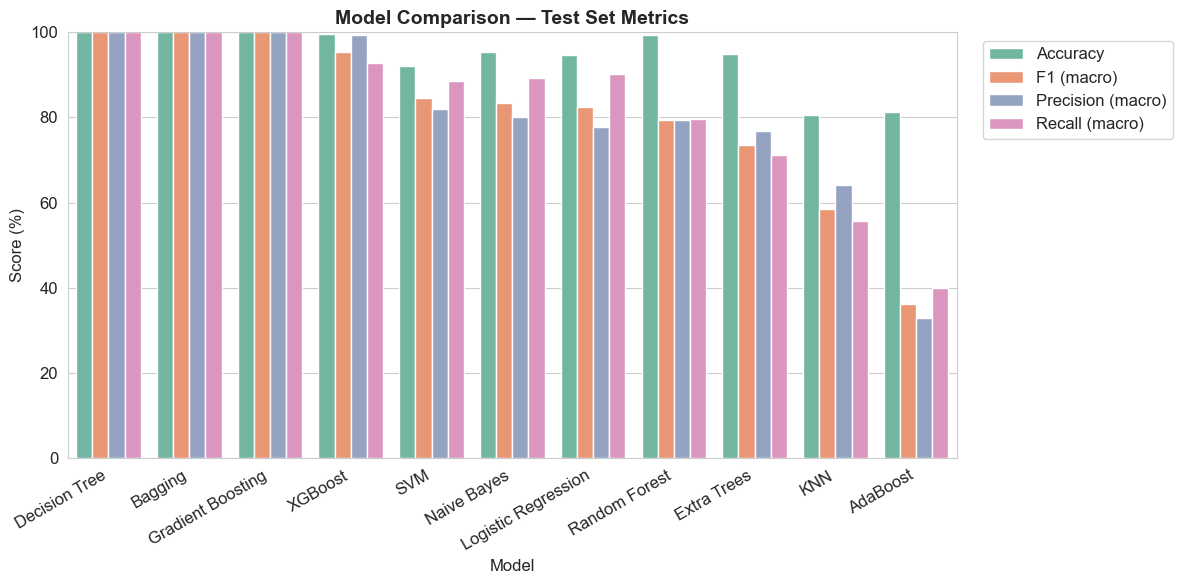

In [37]:
# Updated code
fig, ax = plt.subplots(figsize=(12, 6))

results_melted = results_df.melt(
    id_vars='Model',
    var_name='Metric',
    value_name='Score'
)

sns.barplot(
    data=results_melted,
    x='Model',
    y='Score',
    hue='Metric',
    ax=ax
)

ax.set_title(
    'Model Comparison — Test Set Metrics',
    fontsize=14,
    fontweight='bold'
)

# Percentage scale
ax.set_ylim(0, 100)

ax.set_ylabel('Score (%)')
ax.set_xlabel('Model')

plt.xticks(rotation=30, ha='right')

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

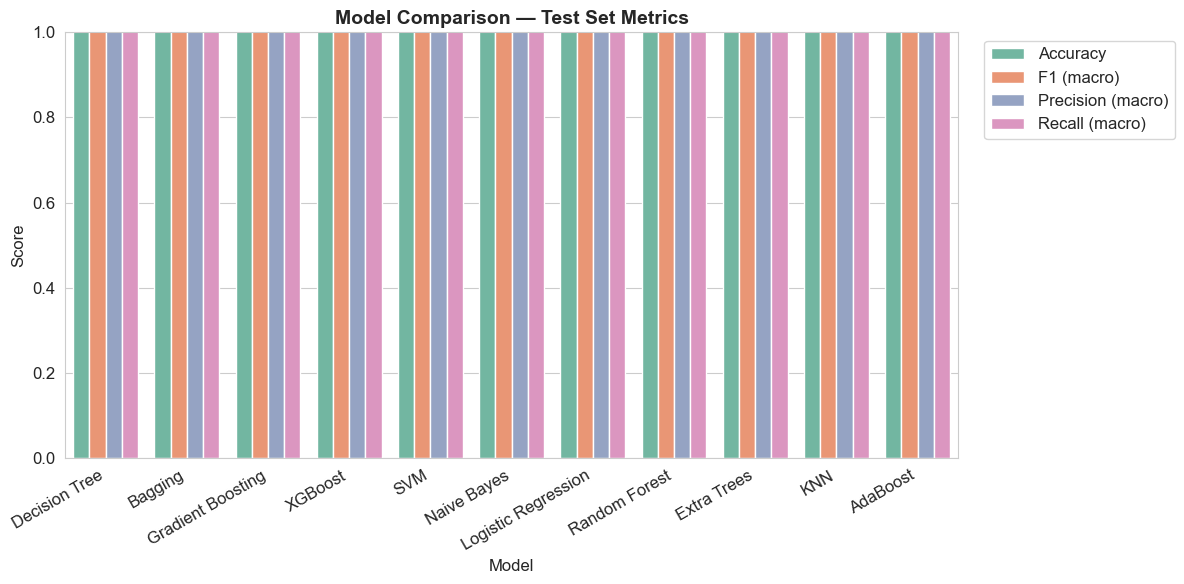

In [38]:
fig, ax = plt.subplots(figsize=(12, 6))
results_melted = results_df.melt(id_vars='Model', var_name='Metric', value_name='Score')
sns.barplot(data=results_melted, x='Model', y='Score', hue='Metric', ax=ax)
ax.set_title('Model Comparison — Test Set Metrics', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1)
plt.xticks(rotation=30, ha='right')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


### Step 11.4 — Select Top Candidate Model


In [39]:
top_model_name = results_df.iloc[0]['Model']
print(f'Top model by F1 (macro): {top_model_name}')
print(results_df.iloc[0])


Top model by F1 (macro): Decision Tree
Model                Decision Tree
Accuracy                     100.0
F1 (macro)                   100.0
Precision (macro)            100.0
Recall (macro)               100.0
Name: 0, dtype: object


## 12. Hyperparameter Tuning


### Step 12.1 — Randomized Search on Random Forest
Tune the Random Forest (a strong, robust candidate) using `RandomizedSearchCV` with stratified
cross-validation, optimizing for macro F1 to fairly weight minority classes.


In [40]:
param_dist = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
}

rf = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    rf, param_distributions=param_dist, n_iter=20, scoring='f1_macro',
    cv=cv, random_state=42, n_jobs=-1, verbose=0
)

random_search.fit(X_train_sc, y_train)

print('Best parameters:')
print(random_search.best_params_)
print(f'\nBest CV F1 (macro): {random_search.best_score_:.4f}')
print(f'\nBest CV F1 (macro): {random_search.best_score_ * 100:.2f}%')

best_model = random_search.best_estimator_


Best parameters:
{'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': None}

Best CV F1 (macro): 0.8974

Best CV F1 (macro): 89.74%


## 13. Final Model Evaluation


### Step 13.1 — Classification Report


In [41]:
y_pred = best_model.predict(X_test_sc)
print(classification_report(y_test, y_pred, target_names=grade_order))


              precision    recall  f1-score   support

           A       1.00      0.33      0.50         3
           B       0.98      1.00      0.99       128
           C       1.00      1.00      1.00       461
           D       1.00      1.00      1.00       352
           F       1.00      1.00      1.00        56

    accuracy                           1.00      1000
   macro avg       1.00      0.87      0.90      1000
weighted avg       1.00      1.00      1.00      1000



### Step 13.2 — Confusion Matrix


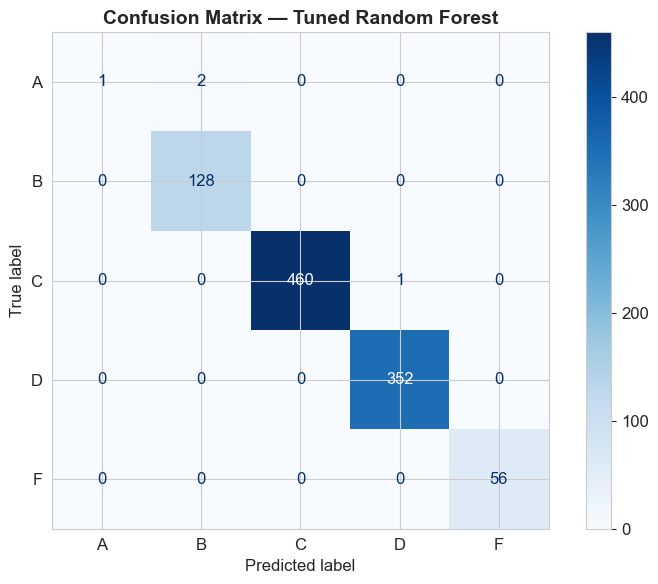

In [42]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=grade_order)
disp.plot(ax=ax, cmap='Blues', colorbar=True)
ax.set_title('Confusion Matrix — Tuned Random Forest', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### Step 13.3 — Final Feature Importance


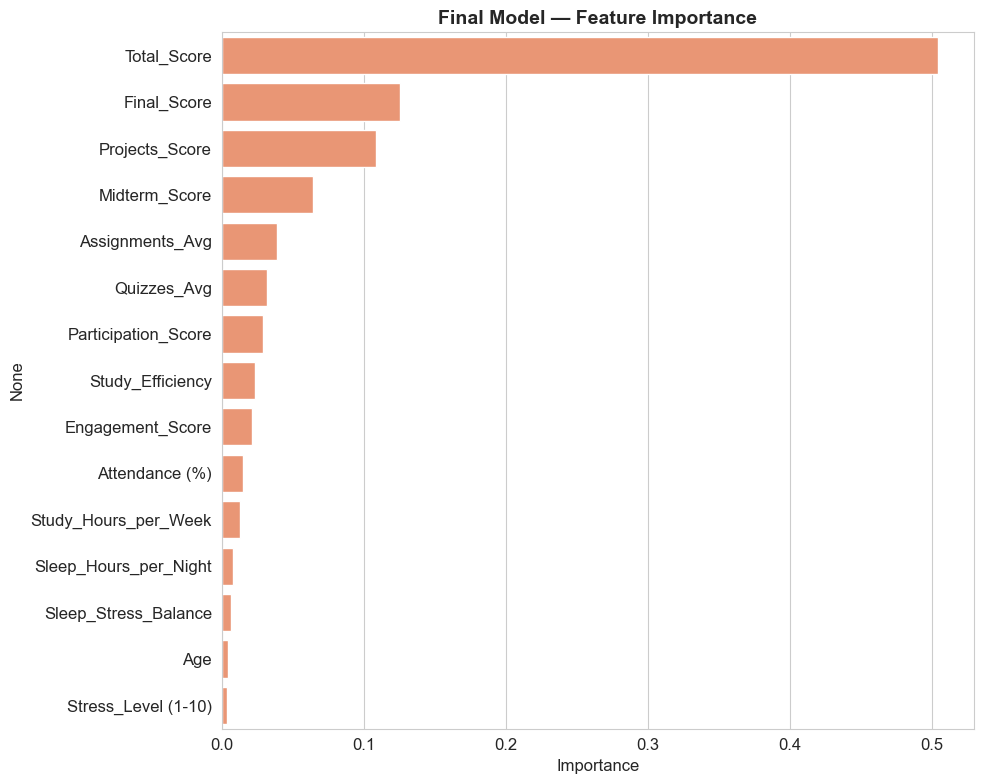

Total_Score              0.504389
Final_Score              0.125875
Projects_Score           0.108996
Midterm_Score            0.064460
Assignments_Avg          0.039310
Quizzes_Avg              0.031860
Participation_Score      0.029356
Study_Efficiency         0.023451
Engagement_Score         0.021614
Attendance (%)           0.015248
Study_Hours_per_Week     0.012621
Sleep_Hours_per_Night    0.007688
Sleep_Stress_Balance     0.006855
Age                      0.004617
Stress_Level (1-10)      0.003660
dtype: float64


In [43]:
final_importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=final_importances.values, y=final_importances.index, color=sns.color_palette('Set2')[1])
plt.title('Final Model — Feature Importance', fontsize=14, fontweight='bold')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print(final_importances)


### Step 13.4 — Cross-Validated Performance Summary


In [44]:
# updated code
cv_scores = cross_val_score(
    best_model,
    X_train_sc,
    y_train,
    cv=cv,
    scoring='f1_macro'
)

print(
    f'Cross-validated F1 (macro): '
    f'{cv_scores.mean() * 100:.2f}% ± {cv_scores.std() * 100:.2f}%'
)

print(
    f'Test set F1 (macro): '
    f'{f1_score(y_test, y_pred, average="macro") * 100:.2f}%'
)

print(
    f'Test set Accuracy: '
    f'{accuracy_score(y_test, y_pred) * 100:.2f}%'
)

Cross-validated F1 (macro): 89.74% ± 6.30%
Test set F1 (macro): 89.79%
Test set Accuracy: 99.70%


In [45]:
cv_scores = cross_val_score(best_model, X_train_sc, y_train, cv=cv, scoring='f1_macro')
print(f'Cross-validated F1 (macro): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print(f'Test set F1 (macro)       : {f1_score(y_test, y_pred, average="macro"):.4f}')
print(f'Test set Accuracy         : {accuracy_score(y_test, y_pred):.4f}')


Cross-validated F1 (macro): 0.8974 ± 0.0630
Test set F1 (macro)       : 0.8979
Test set Accuracy         : 0.9970


## 14. Conclusion & Business Insights


## Preprocessing Decisions Summary Step | Technique Applied | Justification
Identifier Removal | Dropped `Student_ID`, `First_Name`, `Last_Name`, `Email` | No predictive value; pure identifiers
Missing Values | `'Unknown'` category for `Parent_Education_Level` | ~20% missing — preserves rows, lets model learn from "unknown" status
Outlier Detection | IQR analysis on all numerical cols | Outlier % negligible and values valid; no treatment applied
Encoding | Binary mapping for 2-category columns | Simple 0/1 sufficient
Encoding | Ordinal for `Parent_Education_Level`, `Family_Income_Level` | Natural hierarchy exists
Encoding | One-Hot for `Department` | Nominal — no order; avoids false ranking
Feature Engineering | 5 new features created | Domain-driven; validated via correlation/grouping
Feature Selection | RF importance (threshold=0.005) | Removed near-zero-importance features
Scaling | StandardScaler (train fit only) | Required for LR, KNN, SVM, NB; no leakage
Imbalance | `class_weight='balanced'` | Class `A` is extremely rare (~0.3%); SMOTE avoided due to too few minority samples
## Top Predictive Features 1. `Total_Score` — Direct basis of the grading scale; the dominant predictor.
2. `Attendance (%)` / `Engagement_Score` — Strongly tied to performance outcomes.
3. `Study_Hours_per_Week` / `Study_Efficiency` — Captures effort and how effectively it converts to results.
4. `Stress_Level (1-10)` and `Sleep_Stress_Balance` — Wellbeing factors correlate with academic outcomes.
5. `Parent_Education_Level` and `Family_Income_Level` — Background factors show mild influence.
## Business Recommendations 1. Early-warning system — Flag students whose `Is_High_Risk` indicator is 1 (low attendance + high stress) for academic counselling.
2. Attendance interventions — Since attendance strongly tracks with grade outcome, attendance-improvement programs likely yield the highest ROI.
3. Study efficiency coaching — Students with low `Study_Efficiency` despite high `Study_Hours_per_Week` may benefit from study-skills workshops rather than "study more" advice.
4. Wellbeing support — High stress / low sleep students should be directed to wellness resources, as this combination correlates with weaker outcomes.
5. Targeted department support — Departments with skewed grade distributions toward `D`/`F` may need curriculum review.
## Caveats & Next Steps - `Total_Score` is derived directly from the grading formula — a production "early prediction" model (e.g. mid-semester) should exclude `Total_Score`/`Final_Score` and rely on attendance, midterm, assignments, and engagement signals only.
- Class `A` is extremely rare (16/5000) — predictions for this class will have high variance; consider merging `A`/`B` into a single "high performer" class for more stable production use.
- SHAP values could provide per-student explainability for advisors.
- Dataset appears synthetic/illustrative — validate on real institutional data before deployment.
